# Multi-epoch galaxy populations

It is possible to seemlessly create self-consistent mult-epoch galaxy populations. 

This works by defining the characteristics (galaxy stellar mass function, star formation histories) at the final epoch.

A requirement here is the need to provide a function that describes, as a function of the redshift, and final mass, the number of descendents. Using this each projected galaxy is split into several descendents. 

In [1]:
from astropy.cosmology import Planck18 as cosmo
import numpy as np
from synthesizer.grid import Grid
from synthpop.models import Model, Default, Constant
from synthpop.galaxy_populations import MultiEpochGalaxyPopulation
from unyt import yr, Myr, Msun, Gyr, unyt_quantity, Mpc, dimensionless, deg, sr, arcminute


In [2]:
# Define the volume of the galaxy population
volume = 1E5 * Mpc**3

# load default model
model = Default()
model = Constant()

# load grid
grid = Grid("test_grid")

/Users/sw376/Dropbox/Research/projects/synthpop/venv/lib/python3.10/site-packages/unyt/array.py:1900: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


0.0 Myr
7935.542002084362 Myr
10510.05491751732 Myr
11643.13146468227 Myr
12249.273396430466 Myr
12616.179261012536 Myr
12857.620352244136 Myr
----------
SUMMARY OF GALAXY POPULATION
Volume: 1.00e+05 Mpc**3
Redshifts: [0. 1. 2. 3. 4. 5. 6.]
----------



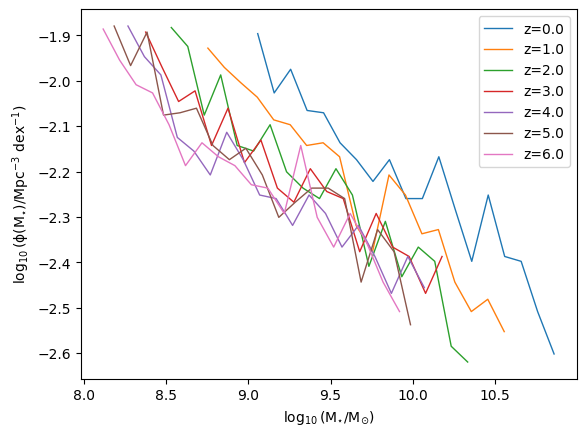

In [3]:

# Instantiate the galaxy population
megp = MultiEpochGalaxyPopulation(
    model=model,
    minimum_stellar_mass=1E9*Msun, 
    maximum_stellar_mass=1E11*Msun, 
    volume=volume,
    grid=grid,
    cosmology=cosmo,
    redshifts=np.arange(0.0, 7.0, 1.0),
    random_seed=42,
    same_galaxies_across_epochs=False,
    )

print(megp)

megp.plot_stellar_mass_function()
